# LINE Embeddings for Contig Binning

LINE preserves first-order graph proximity by training edge endpoints to have high similarity relative to negative samples. Learned graph embeddings are concatenated with RepBin-like node features before clustering.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'LINE'

def train_line(seed, dimensions=32, epochs=180, negative_samples=5, lr=0.025):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    edges = np.transpose(np.nonzero(np.triu(adjacency, k=1)))
    if len(edges) == 0:
        return np.zeros((adjacency.shape[0], dimensions), dtype=np.float32), {'epoch': 0, 'loss': 0.0}
    node_degree = adjacency.sum(axis=1) + 1e-6
    neg_prob = node_degree ** 0.75
    neg_prob = neg_prob / neg_prob.sum()
    emb = nn.Embedding(adjacency.shape[0], dimensions)
    ctx = nn.Embedding(adjacency.shape[0], dimensions)
    nn.init.xavier_uniform_(emb.weight)
    nn.init.xavier_uniform_(ctx.weight)
    opt = torch.optim.Adam(list(emb.parameters()) + list(ctx.parameters()), lr=lr)
    last_loss = 0.0
    for epoch in range(1, epochs + 1):
        rng.shuffle(edges)
        total_loss = 0.0
        for start in range(0, len(edges), 256):
            batch = edges[start:start + 256]
            u = torch.tensor(batch[:, 0], dtype=torch.long)
            v = torch.tensor(batch[:, 1], dtype=torch.long)
            neg = torch.tensor(rng.choice(adjacency.shape[0], size=(len(batch), negative_samples), p=neg_prob), dtype=torch.long)
            opt.zero_grad()
            pos_score = (emb(u) * ctx(v)).sum(dim=1)
            pos_loss = F.logsigmoid(pos_score).mean()
            neg_score = torch.bmm(ctx(neg), emb(u).unsqueeze(2)).squeeze(2)
            neg_loss = F.logsigmoid(-neg_score).mean()
            loss = -(pos_loss + neg_loss)
            loss.backward()
            opt.step()
            total_loss += float(loss.item())
        last_loss = total_loss
    with torch.no_grad():
        embeddings = F.normalize(emb.weight + ctx.weight, p=2, dim=1).cpu().numpy()
    return embeddings, {'epoch': epochs, 'loss': last_loss}

def run_once(seed):
    line_embeddings, history = train_line(seed)
    embeddings = np.hstack([line_embeddings, features])
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics.update({'epochs': history['epoch'], 'loss': history['loss']})
    return metrics


run 01 seed=7: precision=0.5521, recall=0.5521, f1=0.5521, ari=0.1772, nmi=0.3331
run 02 seed=8: precision=0.5285, recall=0.6071, f1=0.5651, ari=0.1654, nmi=0.3362
run 03 seed=9: precision=0.6051, recall=0.5953, f1=0.6002, ari=0.2446, nmi=0.3904
run 04 seed=10: precision=0.5108, recall=0.5776, f1=0.5422, ari=0.1518, nmi=0.3067
run 05 seed=11: precision=0.5305, recall=0.6130, f1=0.5687, ari=0.1684, nmi=0.3336
run 06 seed=12: precision=0.5422, recall=0.5855, f1=0.5630, ari=0.1715, nmi=0.3385
run 07 seed=13: precision=0.5344, recall=0.6012, f1=0.5658, ari=0.1688, nmi=0.3381
run 08 seed=14: precision=0.5069, recall=0.5933, f1=0.5467, ari=0.1569, nmi=0.3043
run 09 seed=15: precision=0.5540, recall=0.5619, f1=0.5579, ari=0.1748, nmi=0.3360
run 10 seed=16: precision=0.6306, recall=0.7151, f1=0.6702, ari=0.2609, nmi=0.3532


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.552063,0.552063,0.552063,0.177153,0.333091,5,5,0.410380,180,0.484874
1,2,8,0.528487,0.607073,0.565061,0.165440,0.336235,5,5,0.368850,180,0.573394
2,3,9,0.605108,0.595285,0.600156,0.244573,0.390404,5,5,0.466382,180,0.598689
3,4,10,0.510806,0.577603,0.542155,0.151816,0.306692,5,5,0.341036,180,0.542079
4,5,11,0.530452,0.612967,0.568732,0.168438,0.333648,5,5,0.377512,180,0.518269
5,6,12,0.542240,0.585462,0.563022,0.171490,0.338490,5,5,0.386891,180,0.414606
6,7,13,0.534381,0.601179,0.565815,0.168776,0.338141,5,5,0.379325,180,0.906444
7,8,14,0.506876,0.593320,0.546702,0.156881,0.304307,5,5,0.344740,180,0.392266
8,9,15,0.554028,0.561886,0.557929,0.174760,0.335990,5,5,0.403253,180,0.685868
9,10,16,0.630648,0.715128,0.670236,0.260860,0.353154,5,5,0.377026,180,0.508346


,min,max,mean,std
precision,0.506876,0.630648,0.549509,0.039587
recall,0.552063,0.715128,0.600196,0.044726
f1,0.542155,0.670236,0.573187,0.037613
ari,0.151816,0.260860,0.184019,0.037201
nmi,0.304307,0.390404,0.337015,0.023879
aligned_macro_f1,0.341036,0.466382,0.385539,0.035851


<Axes: title={'center': 'LINE: mean metrics over 10 runs'}, ylabel='score'>

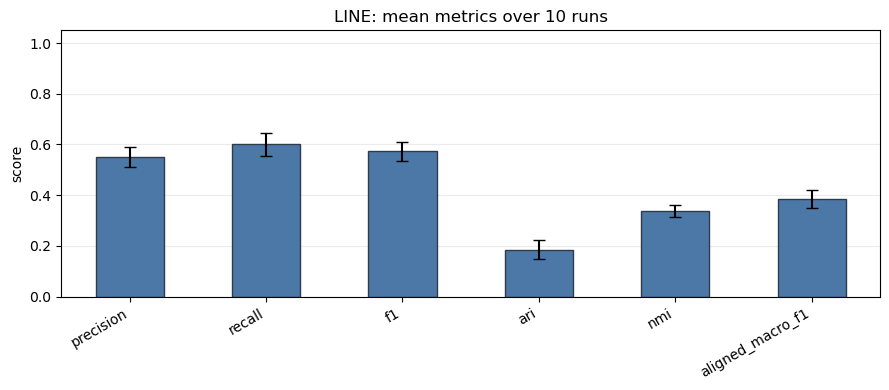

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.5520628683693517, 'recall': 0.5520628683693517, 'f1': 0.5520628683693517, 'ari': 0.17715282140789346, 'nmi': 0.33309143773591177, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.4103801102948224, 'epochs': 180, 'loss': 0.4848740231245756}
LINE: assembly graph coloured by predicted bin
bin 0: 203 contigs
bin 1: 42 contigs
bin 2: 12 contigs
bin 3: 83 contigs
bin 4: 169 contigs


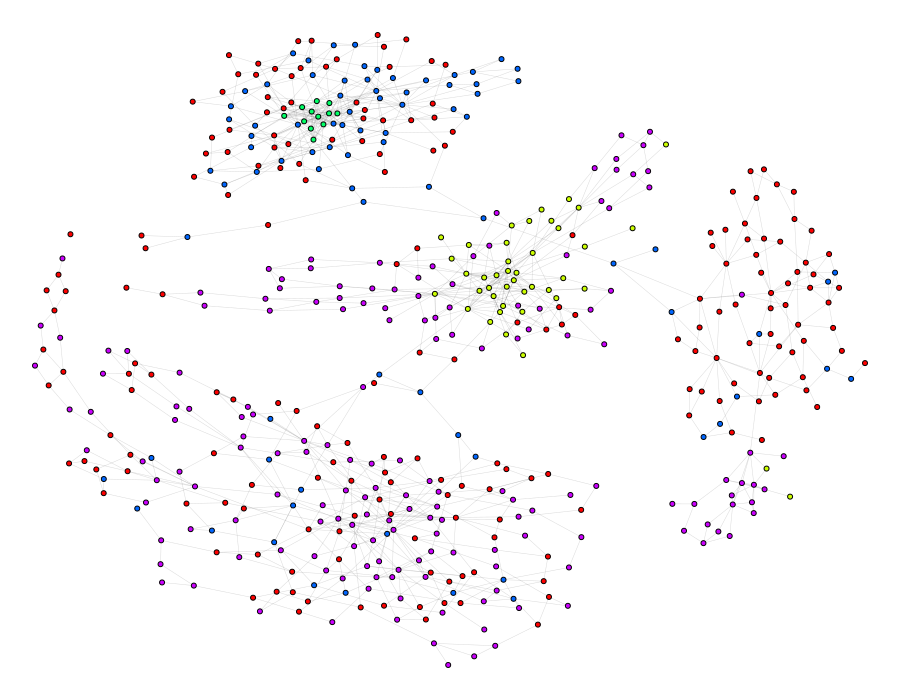

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.552063,0.552063,0.552063,0.177153,0.333091,5,5,0.410380,180,0.484874
1,original assembly graph,2,8,0.528487,0.607073,0.565061,0.165440,0.336235,5,5,0.368850,180,0.573394
2,original assembly graph,3,9,0.605108,0.595285,0.600156,0.244573,0.390404,5,5,0.466382,180,0.598689
3,original assembly graph,4,10,0.510806,0.577603,0.542155,0.151816,0.306692,5,5,0.341036,180,0.542079
4,original assembly graph,5,11,0.530452,0.612967,0.568732,0.168438,0.333648,5,5,0.377512,180,0.518269
5,original assembly graph,6,12,0.542240,0.585462,0.563022,0.171490,0.338490,5,5,0.386891,180,0.414606
6,original assembly graph,7,13,0.534381,0.601179,0.565815,0.168776,0.338141,5,5,0.379325,180,0.906444
7,original assembly graph,8,14,0.506876,0.593320,0.546702,0.156881,0.304307,5,5,0.344740,180,0.392266
8,original assembly graph,9,15,0.554028,0.561886,0.557929,0.174760,0.335990,5,5,0.403253,180,0.685868
9,original assembly graph,10,16,0.630648,0.715128,0.670236,0.260860,0.353154,5,5,0.377026,180,0.508346


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.506876  0.630648  0.549509  0.039587   
random edge removal              0.500982  0.660118  0.585855  0.055373   
random edge addition             0.508841  0.648330  0.554617  0.040709   
coverage-similarity edges added  0.532417  0.664047  0.602554  0.048770   
short contigs removed            0.484444  0.691111  0.565778  0.079257   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.552063  0.715128  0.600196  0.044726   
random edge removal              0.548134  0.738703  0.626130  0.070484   
random edge addition             0.544204  0.724951  0.587033  0.051945   
coverage-similarity edges added  0.550098  0.748527  0.624754  0.074027   
short contigs removed            0.617778  0.784444  0.682444  0.062910   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.542155  0.670236  ...  0.184019  0.037201   
random edge removal              0.537417  0.697203  ...  0.232041  0.073484   
random edge addition             0.549072  0.684503  ...  0.191777  0.048146   
coverage-similarity edges added  0.549530  0.701548  ...  0.246622  0.067587   
short contigs removed            0.552924  0.734826  ...  0.251045  0.084235   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.304307  0.390404  0.337015  0.023879   
random edge removal              0.293797  0.423484  0.365062  0.043002   
random edge addition             0.316272  0.409549  0.343786  0.027392   
coverage-similarity edges added  0.309433  0.414106  0.373940  0.038629   
short contigs removed            0.331326  0.466985  0.380084  0.047725   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.341036  0.466382  0.385539  0.035851  
random edge removal                     0.334389  0.462407  0.402102  0.034838  
random edge addition                    0.339748  0.445579  0.394194  0.034934  
coverage-similarity edges added         0.378073  0.492010  0.425628  0.035740  
short contigs removed                   0.323828  0.458825  0.396433  0.044019  

[5 rows x 24 columns]

<Axes: title={'center': 'LINE: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

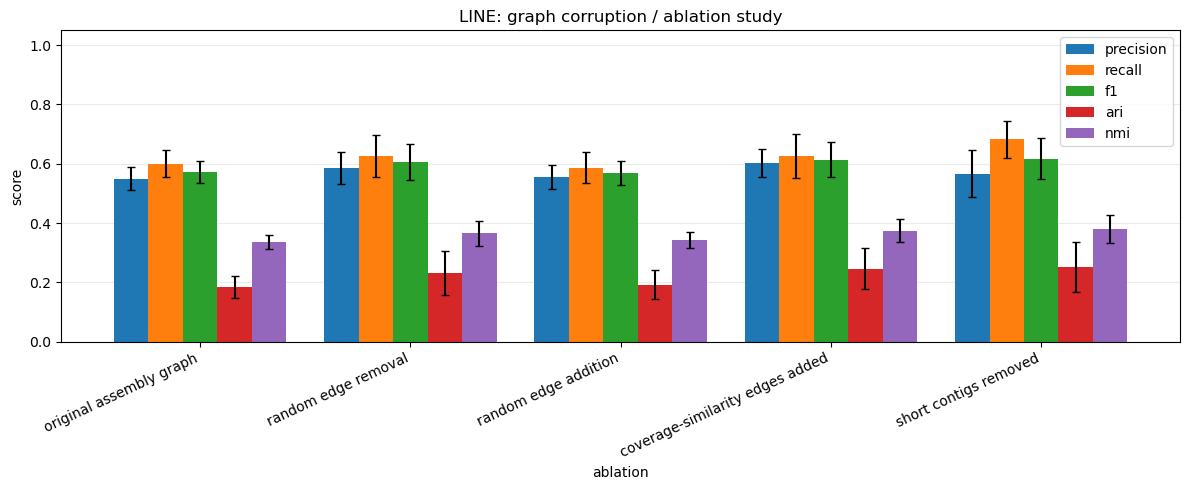

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
